# Day 03 — Độ ổn định của mô hình

[Slide của buổi học](_static/slides/day03_slides.pptx)

## Mục tiêu

- Chạy 5 fold cross validation cho ring1
- Dùng bootstrap để có khoảng tin cậy cho AUC
- Nhìn ra một ví dụ leakage
- Viết được ba câu nhận xét về độ ổn định

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import mannwhitneyu

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def raw_url(relative_path):
    return f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/{relative_path}"

def load_csv(relative_repo_path):
    local_candidates = [
        Path(relative_repo_path),
        Path("..") / relative_repo_path,
        Path("/content") / REPO_NAME / relative_repo_path,
    ]
    for p in local_candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.read_csv(raw_url(relative_repo_path))

def build_lr_pipeline(feature_list, cat_cols):
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), [c for c in feature_list if c in cat_cols]),
    ])
    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    return pipe

In [2]:
df = load_csv('data/nsclc_egfr_radiomics_simplified.csv')

target = 'egfr_mutation'
clinical = ['age','sex','smoking_status','histology','stage','tumor_size_mm','tumor_volume_cm3','tp53_mutation']
cat_cols = ['sex','smoking_status','histology','stage']
ring1 = [c for c in df.columns if c.startswith('ring1_')]
feature_list = clinical + ring1
y = df[target]

pipe = build_lr_pipeline(feature_list, cat_cols)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Bước 1 — 5 fold cross validation

Mỗi fold cho một AUC. Nhìn cả dãy AUC sẽ hiểu mô hình dao động ra sao.

,fold,auc,accuracy
0,1,0.747,0.700
1,2,0.833,0.775
2,3,0.785,0.675
3,4,0.778,0.650
4,5,0.909,0.825


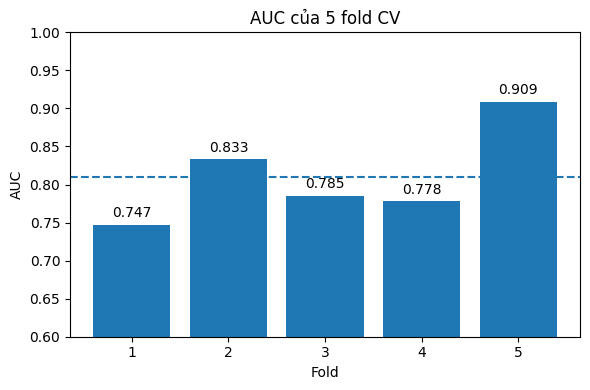

In [3]:
cv_result = cross_validate(
    pipe,
    df[feature_list],
    y,
    cv=cv,
    scoring=['roc_auc', 'accuracy'],
    return_train_score=False
)

cv_table = pd.DataFrame({
    'fold': [1, 2, 3, 4, 5],
    'auc': cv_result['test_roc_auc'].round(3),
    'accuracy': cv_result['test_accuracy'].round(3)
})
display(cv_table)

plt.figure(figsize=(6, 4))
plt.bar(cv_table['fold'].astype(str), cv_table['auc'])
plt.axhline(cv_table['auc'].mean(), linestyle='--')
for i, v in enumerate(cv_table['auc']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.ylim(0.6, 1.0)
plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('AUC của 5 fold CV')
plt.tight_layout()
plt.show()

## Bước 2 — Bootstrap AUC trên tập test

Cross validation trả lời câu hỏi mô hình có ổn định giữa các fold hay không. Bootstrap trả lời thêm câu hỏi AUC dao động ra sao khi lấy mẫu lại nhiều lần.

Mean AUC 0.816
95 percent CI 0.687 đến 0.923


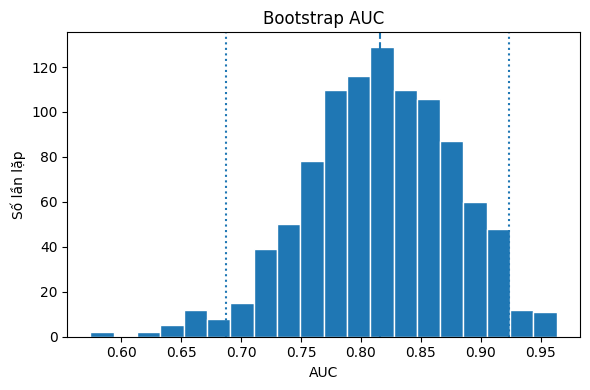

In [4]:
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.25,
    stratify=df[target],
    random_state=42
)
y_train = df.loc[idx_train, target]
y_test = df.loc[idx_test, target]

pipe.fit(df.loc[idx_train, feature_list], y_train)
pred_prob = pipe.predict_proba(df.loc[idx_test, feature_list])[:, 1]

rng = np.random.default_rng(42)
bootstrap_aucs = []
y_test_arr = y_test.to_numpy()

for _ in range(1000):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    if len(np.unique(y_test_arr[idx])) < 2:
        continue
    bootstrap_aucs.append(roc_auc_score(y_test_arr[idx], pred_prob[idx]))

ci_low, ci_high = np.quantile(bootstrap_aucs, [0.025, 0.975])
print('Mean AUC', round(np.mean(bootstrap_aucs), 3))
print('95 percent CI', round(ci_low, 3), 'đến', round(ci_high, 3))

plt.figure(figsize=(6, 4))
plt.hist(bootstrap_aucs, bins=20, edgecolor='white')
plt.axvline(np.mean(bootstrap_aucs), linestyle='--')
plt.axvline(ci_low, linestyle=':')
plt.axvline(ci_high, linestyle=':')
plt.xlabel('AUC')
plt.ylabel('Số lần lặp')
plt.title('Bootstrap AUC')
plt.tight_layout()
plt.show()

## Bước 3 — Nhìn ví dụ leakage

Ví dụ này dùng dữ liệu toy. Mục tiêu là thấy vì sao chọn đặc trưng trước khi chia tập sẽ làm AUC đẹp giả.

,Cách làm,AUC
0,Chọn đặc trưng trước khi chia tập,0.785
1,Chọn đặc trưng bên trong pipeline,0.547


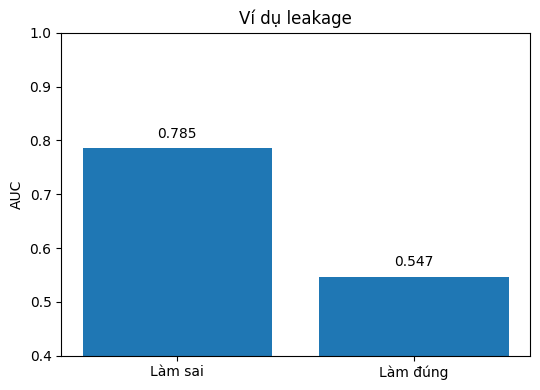

In [5]:
X_toy, y_toy = make_classification(
    n_samples=200,
    n_features=100,
    n_informative=5,
    n_redundant=5,
    flip_y=0.05,
    class_sep=0.8,
    random_state=42
)

selector = SelectKBest(f_classif, k=10)
X_wrong = selector.fit_transform(X_toy, y_toy)
X_tr, X_te, y_tr, y_te = train_test_split(X_wrong, y_toy, test_size=0.3, stratify=y_toy, random_state=42)

wrong_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
wrong_pipe.fit(X_tr, y_tr)
auc_wrong = roc_auc_score(y_te, wrong_pipe.predict_proba(X_te)[:, 1])

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_toy, y_toy, test_size=0.3, stratify=y_toy, random_state=42)
right_pipe = Pipeline([
    ('select', SelectKBest(f_classif, k=10)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
right_pipe.fit(X_tr2, y_tr2)
auc_right = roc_auc_score(y_te2, right_pipe.predict_proba(X_te2)[:, 1])

leakage_table = pd.DataFrame({
    'Cách làm': ['Chọn đặc trưng trước khi chia tập', 'Chọn đặc trưng bên trong pipeline'],
    'AUC': [round(auc_wrong, 3), round(auc_right, 3)]
})
display(leakage_table)

plt.figure(figsize=(5.5, 4))
plt.bar(['Làm sai', 'Làm đúng'], [auc_wrong, auc_right])
for i, v in enumerate([auc_wrong, auc_right]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Ví dụ leakage')
plt.tight_layout()
plt.show()

## Kết quả demo của Day 03

- Mean AUC của 5 fold CV là 0.81
- Độ lệch chuẩn giữa các fold là 0.057
- Bootstrap mean AUC là 0.816
- Khoảng tin cậy 95 phần trăm là từ 0.687 đến 0.923

Điểm cần nhớ nhất của Day 03 là không được làm feature selection quá sớm. Trong ví dụ leakage, AUC làm sai là 0.785 còn làm đúng chỉ là 0.547.

## Sản phẩm sau bài học

- Một bảng AUC của 5 fold
- Một histogram bootstrap
- Một ví dụ leakage rất ngắn
- Ba câu nhận xét về độ ổn định

## Tự kiểm tra

1. Cross validation trả lời câu hỏi gì
2. Bootstrap trả lời câu hỏi gì
3. Leakage thường xuất hiện ở bước nào